In [5]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
data_generator = ImageDataGenerator(
    rescale=1./255.,
    zoom_range=0.4,
    horizontal_flip=True, 
    vertical_flip=True,
    rotation_range=50,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.4,
    fill_mode='nearest'
)

train_data = data_generator.flow_from_directory(
    'data\PetImage', class_mode='binary', batch_size=50, target_size=(200, 200))

Found 16139 images belonging to 2 classes.


In [4]:
test_data = data_generator.flow_from_directory(
    'data\PetImagesTest', class_mode='binary', batch_size=50, target_size=(200, 200))

Found 1666 images belonging to 2 classes.


In [6]:
model = Sequential([
    Input(shape=(200, 200, 3)),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    MaxPool2D((2, 2)),
    Flatten(),
    Dense(1, activation='sigmoid')

])

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 320000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │       320,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,897 (1.22 MB)

 Trainable params: 320,897 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer=Adam(), loss='binary_crossentropy',
              metrics=['accuracy'])

In [18]:
history = model.fit(train_data, epochs=30, validation_data=test_data)

Epoch 1/30
323/323 ━━━━━━━━━━━━━━━━━━━━ 277s 856ms/step - accuracy: 0.5654 - loss: 0.8336 - val_accuracy: 0.6074 - val_loss: 0.6675
Epoch 2/30
323/323 ━━━━━━━━━━━━━━━━━━━━ 165s 512ms/step - accuracy: 0.6005 - loss: 0.6606 - val_accuracy: 0.6050 - val_loss: 0.6490
Epoch 3/30
323/323 ━━━━━━━━━━━━━━━━━━━━ 165s 511ms/step - accuracy: 0.5971 - loss: 0.6589 - val_accuracy: 0.5972 - val_loss: 0.6472
Epoch 4/30
323/323 ━━━━━━━━━━━━━━━━━━━━ 161s 500ms/step - accuracy: 0.6055 - loss: 0.6553 - val_accuracy: 0.6026 - val_loss: 0.6479
Epoch 5/30
323/323 ━━━━━━━━━━━━━━━━━━━━ 162s 501ms/step - accuracy: 0.6064 - loss: 0.6521 - val_accuracy: 0.6212 - val_loss: 0.6418
Epoch 6/30
323/323 ━━━━━━━━━━━━━━━━━━━━ 162s 500ms/step - accuracy: 0.6022 - loss: 0.6562 - val_accuracy: 0.6110 - val_loss: 0.6405
Epoch 7/30
323/323 ━━━━━━━━━━━━━━━━━━━━ 162s 501ms/step - accuracy: 0.6095 - loss: 0.6522 - val_accuracy: 0.6092 - val_loss: 0.6354
Epoch 8/30
323/323 ━━━━━━━━━━━━━━━━━━━━ 163s 506ms/step - accuracy: 0.6086 -

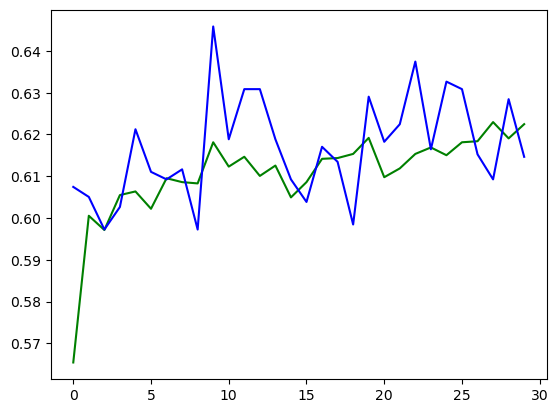

In [22]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color='green')
plt.plot(history.history['val_accuracy'], color='blue')